In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import sys

sys.path.append("../src")

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np 
from games.prisoners_dilemma import play_round
from games.prisoners_dilemma import total_payoffs_network
from games.prisoners_dilemma import new_population

# Games on network, figuring out implementation

## Testing a simple population and network example

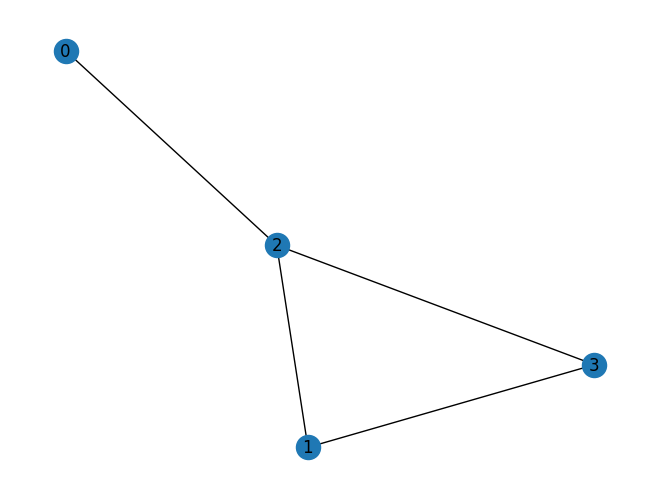

In [4]:
population = np.array([True, True, False, False])

G = nx.Graph()
G.add_nodes_from(range(len(population)))
G.add_edges_from([(1,2),(2,0),(3,2),(3,1)])

nx.draw(G, with_labels = True)

Now we have to compute 1's neighbours

In [5]:
for i in range(len(population)):
    neighbors = list(G.neighbors(i))
    print(f"Node {i} has the following neighbors: {neighbors}")


Node 0 has the following neighbors: [2]
Node 1 has the following neighbors: [2, 3]
Node 2 has the following neighbors: [1, 0, 3]
Node 3 has the following neighbors: [2, 1]


We have to modify our payoffs function so that agents only play with their neighbors.

In [6]:
def total_payoffs_network(population,G):
    payoffs = np.zeros(len(population))

    for i, strategy_i in enumerate(population):
        for j in list(G.neighbors(i)):
            if i == j:
                continue
            payoff_i, payoff_j = play_round(population[i],population[j])
            payoffs[i] += payoff_i
            # print(f"Agent {i} vs Agent {j}: {population[i]} vs {population[j]} -> payoff_i={payoff_i}, accumulated={payoffs[i]}")
    return np.array(payoffs)

In [7]:
test = total_payoffs_network(population)

print(test)

TypeError: total_payoffs_network() missing 1 required positional argument: 'G'

To make sure that the model is working correctly, we can compute this example by hand.


### Agent A (Cooperator)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |    CD     |   0     |
| **Total** |         |    0    |

### Agent B (Cooperator)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |   CD      |   0     |
|     D     |     CD    |     0   |
| **Total** |         |        |

### Agent C (Defector)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     B      |   DC      |    5    |
|     A     |     DC    |    5    |
|     D     |    DD     |    1    |
| **Total** |         |     11   |

### Agent D (Defector)

| Opponent | Outcome | Payoff |
|:--------:|:-------:|------:|
|     C      |    DD     |   1     |
|     B      |     DC    |     5   |
| **Total** |         |    6    |


Yes, it works.

## Complete game with network dyamic

To ilustrate this game we have to generate a better graph and population.

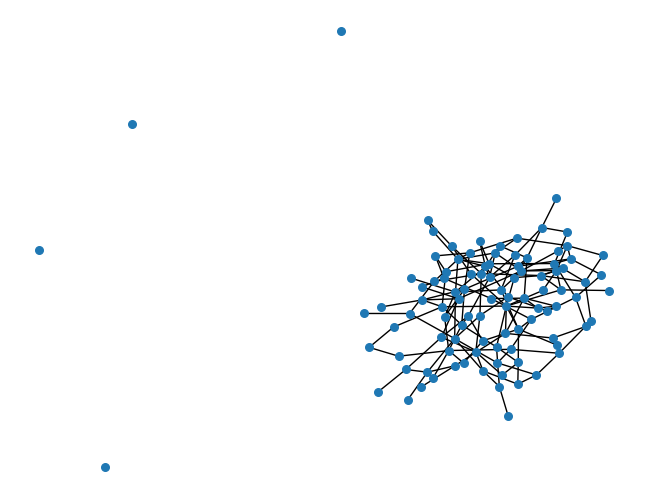

In [52]:
number_of_agents = 100

#Erdos renyi
p_edge = 0.03
G1 = nx.erdos_renyi_graph(number_of_agents, p_edge, seed = 67)

G = G1

p_coop = 0.5
population = np.random.binomial(1, p_coop, size = number_of_agents).astype(bool)

nx.draw(G, node_size = 30)
plt.show()

In [39]:
degrees = [d for n, d in G.degree()]
print(np.mean(degrees))

3.24


In [40]:
N = 100
coperatio = []# ratio of cooperators

for generation in range(N):
    payoffs = total_payoffs_network(population, G)
    population = new_population(population,payoffs,G)
    coperatio.append(np.mean(population))

In [41]:
payoffs = total_payoffs_network(population, G)
print(payoffs[:10])  # ¿hay ceros ahí? ¿algún NaN?

new_pop = new_population(population, payoffs, G)
print(np.mean(new_pop))
print(new_pop[:10])

[6. 5. 2. 3. 1. 5. 5. 4. 3. 2.]
0.03
[False False False False False False False False False False]


Plotting the ratio of cooperators we get:

[0.18, 0.06, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03]


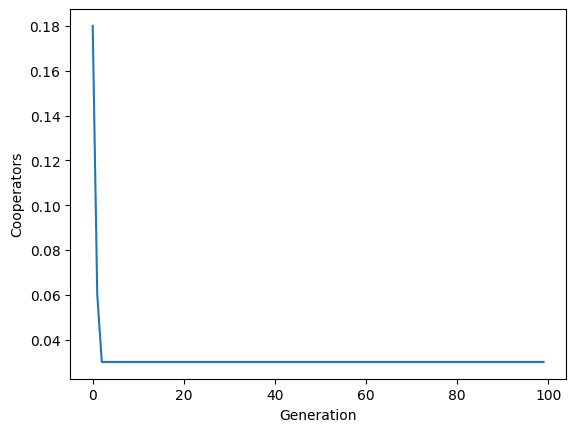

In [ ]:
print([round(float(x),3) for x in coperatio])


plt.plot(coperatio)
plt.xlabel("Generation")
plt.ylabel("Cooperators")
plt.show()

'''
xaxis = np.arange(len(x_record))

plt.figure(figsize=(8,4), dpi=200)

plt.plot(xaxis,x_record, color = "black")
plt.fill_between(xaxis,0,x_record, color ="green", alpha = 0.5, label = "Cooperators")
plt.fill_between(xaxis,x_record,1, color = "red", alpha = 0.5, label = "Defectors")

plt.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.xlabel("Generation")
plt.title("Replicator Dynamics")
plt.grid(alpha = 0.3)
plt.show()
'''